# M2 — Centroid Tracking + Structure Function

**Objetivo:** caracterizar el *tilt* atmosférico temporal a partir de secuencias de imágenes solares del dataset **SUTO-Solar-TTOD**.

### Idea del método
1. Para cada frame $t$ de la secuencia se estima la posición del centroide $\mathbf{r}(t) = (x(t), y(t))$ de la distribución de intensidad.
2. Se calcula la **structure function** de la posición:
$$D(\tau) \;=\; \bigl\langle \|\mathbf{r}(t+\tau) - \mathbf{r}(t)\|^{2}\bigr\rangle_{t}$$
3. En el régimen inercial de Kolmogorov se espera la ley de potencia:
$$D(\tau) \;\propto\; \tau^{5/3}$$
4. La saturación de $D(\tau)$ define el **tiempo de coherencia atmosférico** $t_{0}$ (escala de tiempo a la cual el tilt se decorrelaciona).

### Por qué tiene sentido en este dataset
- Cada cubo FITS contiene 100 frames temporales del mismo parche solar → el centroide se desplaza únicamente por turbulencia (la escena es estática a esa escala).
- La cromosfera (Lunt60) y la fotosfera (ED80) tienen estructura suficiente para que el centroide ponderado por intensidad sea estable y sensible al tilt.

## 1. Imports y configuración

In [4]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

DATASET_DIR = Path('Dataset')
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.dpi'] = 110
np.set_printoptions(precision=4, suppress=True)

## 2. I/O — Listado y carga de archivos FITS

- `list_fits_files`: enumera los cubos del dataset, filtrando opcionalmente por tipo (`chromosphere` / `continuum`), resolución (`100p` / `200p`) y excluyendo los MFBD por defecto (estos son la referencia *ground-truth-like*, no la entrada cruda).
- `load_fits_cube`: abre el archivo con `with`, devuelve el cubo en `float32` y un dict con metadatos relevantes.
- Las dimensiones del cubo son `(T, H, W)` donde `T == NAXIS3`.

In [5]:
FNAME_RE = re.compile(r'^(?P<kind>chromosphere|continuum)_(?P<pix>\d+)p_(?P<num>\d+)(?P<mfbd>_MFBD)?\.fits$')

def list_fits_files(dataset_dir=DATASET_DIR, kind=None, pix=None, include_mfbd=False):
    """Lista FITS del dataset con filtros por tipo / resolución / MFBD."""
    files = []
    for p in sorted(Path(dataset_dir).glob('*.fits')):
        m = FNAME_RE.match(p.name)
        if not m:
            continue
        is_mfbd = bool(m.group('mfbd'))
        if is_mfbd and not include_mfbd:
            continue
        if kind is not None and m.group('kind') != kind:
            continue
        if pix is not None and int(m.group('pix')) != pix:
            continue
        files.append(p)
    return files


def load_fits_cube(path):
    """Carga un FITS como cubo (T, H, W) float32 + metadatos."""
    with fits.open(path, memmap=False) as hdul:
        data = np.asarray(hdul[0].data, dtype=np.float32)
        hdr = hdul[0].header
        meta = {
            'name': Path(path).name,
            'exposure_us': float(hdr.get('EXPOSURE', np.nan)),
            'instrume': hdr.get('INSTRUME', ''),
            'naxis3': int(hdr.get('NAXIS3', data.shape[0] if data.ndim == 3 else 1)),
            'envdata': hdr.get('ENVDATA', ''),
        }
    if data.ndim == 2:
        data = data[np.newaxis, ...]
    return data, meta


all_files = list_fits_files(kind='chromosphere', pix=100)
print(f'Archivos disponibles (chromosphere 100p, sin MFBD): {len(all_files)}')
if all_files:
    cube, meta = load_fits_cube(all_files[0])
    print(f'Ejemplo: {meta["name"]}  shape={cube.shape}  EXPOSURE={meta["exposure_us"]} us  INSTRUME={meta["instrume"]}')

Archivos disponibles (chromosphere 100p, sin MFBD): 100
Ejemplo: chromosphere_100p_00100.fits  shape=(100, 100, 100)  EXPOSURE=30000.0 us  INSTRUME=Lunt60 ASIZWO183MM


## 3. Estimación del centroide por frame

Usamos el **centroide ponderado por intensidad** (primer momento de la distribución):
$$x_c \;=\; \frac{\sum_{i,j} I(i,j)\, j}{\sum_{i,j} I(i,j)}, \qquad y_c \;=\; \frac{\sum_{i,j} I(i,j)\, i}{\sum_{i,j} I(i,j)}$$

**Pre-procesado por frame:**
1. Sustracción del fondo: $I' = \max(I - \mathrm{median}(I)\cdot k,\;0)$ con $k\in[0,1]$ para realzar la estructura sin sesgar el centroide hacia el centro geométrico.
2. Opcionalmente se restringe el cálculo a una ventana central de la imagen.

El resultado es una serie temporal `centroids[t] = (x(t), y(t))` con `shape = (T, 2)` en píxeles.

In [6]:
def compute_centroids(cube, bg_frac=1.0, window=None):
    """Centroide ponderado por intensidad para cada frame del cubo.

    cube     : ndarray (T, H, W)
    bg_frac  : fracción de la mediana que se resta como fondo (0..1)
    window   : (y0, y1, x0, x1) o None  -> rectángulo en el frame completo

    Returns: ndarray (T, 2) con columnas (x, y) en píxeles.
    """
    cube = np.asarray(cube, dtype=np.float32)
    T, H, W = cube.shape
    if window is None:
        y0, y1, x0, x1 = 0, H, 0, W
    else:
        y0, y1, x0, x1 = window
    yy, xx = np.mgrid[y0:y1, x0:x1].astype(np.float32)

    centroids = np.full((T, 2), np.nan, dtype=np.float64)
    for t in range(T):
        frame = cube[t, y0:y1, x0:x1]
        bg = bg_frac * np.median(frame)
        f = frame - bg
        np.clip(f, 0.0, None, out=f)
        total = f.sum()
        if total <= 0:
            continue
        centroids[t, 0] = (f * xx).sum() / total  # x
        centroids[t, 1] = (f * yy).sum() / total  # y
    return centroids

## 4. Structure function temporal

Para cada *lag* $\tau$ se promedian todos los pares disponibles dentro de la serie:
$$D(\tau) \;=\; \frac{1}{T-\tau} \sum_{t=0}^{T-\tau-1} \bigl\|\mathbf{r}(t+\tau) - \mathbf{r}(t)\bigr\|^{2}$$

Se devuelve además el número efectivo de pares por lag (útil para ponderar el ajuste o descartar lags con poca estadística).

In [7]:
def structure_function(centroids, max_lag=None):
    """D(tau) = <|r(t+tau) - r(t)|^2>_t.

    Returns: taus (L,), D (L,) en px^2, n (L,) número de pares por lag.
    """
    r = np.asarray(centroids, dtype=np.float64)
    T = r.shape[0]
    if max_lag is None:
        max_lag = T // 2
    max_lag = max(1, min(max_lag, T - 1))

    taus = np.arange(1, max_lag + 1)
    D = np.full(len(taus), np.nan)
    n = np.zeros(len(taus), dtype=int)
    for i, tau in enumerate(taus):
        diff = r[tau:] - r[:-tau]
        sq = np.sum(diff * diff, axis=1)
        mask = np.isfinite(sq)
        n[i] = int(mask.sum())
        if n[i] > 0:
            D[i] = sq[mask].mean()
    return taus, D, n

## 5. Ajuste de la ley de potencia 5/3 y estimación de $t_{0}$

Modelo en el régimen inercial ($\tau \ll t_{0}$):
$$\log D(\tau) \;=\; \log A \;+\; \alpha \, \log \tau$$
con $\alpha \approx 5/3$ esperado por Kolmogorov.

El ajuste se hace en log-log restringido a un rango de lags **antes** de la saturación. El **tiempo de coherencia** $t_{0}$ se estima como el primer $\tau$ en el cual $D(\tau)$ alcanza una fracción `sat_frac` (por defecto 0.86) del nivel de saturación $D_{\infty} = 2\,\mathrm{Var}(\mathbf{r})$.

In [8]:
def fit_power_law(taus, D, fit_range=None):
    """log D = log A + alpha log tau sobre un rango de lags."""
    taus = np.asarray(taus, dtype=np.float64)
    D = np.asarray(D, dtype=np.float64)
    if fit_range is None:
        tmax = max(2, len(taus) // 3)
        fit_range = (1, tmax)
    lo, hi = fit_range
    mask = (taus >= lo) & (taus <= hi) & np.isfinite(D) & (D > 0)
    if mask.sum() < 2:
        return np.nan, np.nan, mask
    alpha, logA = np.polyfit(np.log(taus[mask]), np.log(D[mask]), 1)
    return alpha, np.exp(logA), mask


def coherence_time(centroids, taus, D, sat_frac=0.86):
    """Tiempo de coherencia en frames: primer tau con D(tau) >= sat_frac * 2 Var(r)."""
    r = np.asarray(centroids, dtype=np.float64)
    r = r[np.all(np.isfinite(r), axis=1)]
    if len(r) < 2:
        return np.nan, np.nan
    D_inf = 2.0 * (np.var(r[:, 0]) + np.var(r[:, 1]))
    target = sat_frac * D_inf
    above = np.where(D >= target)[0]
    if len(above) == 0:
        return np.nan, D_inf
    return float(taus[above[0]]), D_inf

## 6. Pipeline por archivo

Junta todo: carga del cubo → centroides → structure function → ajuste 5/3 → $t_{0}$.

El paso temporal `dt` se toma del header `EXPOSURE` (µs → s) como **mejor aproximación disponible** de la cadencia frame-a-frame. Esto ignora el tiempo de readout, así que `t0_seconds` es una *cota inferior*; los resultados en *frames* son independientes de esa suposición.

In [9]:
def process_file(path, bg_frac=1.0, window=None, max_lag=None, fit_range=None,
                 sat_frac=0.86):
    """Pipeline completo por archivo.

    Estrategia de ajuste:
    - Si `fit_range` se da, se usa tal cual.
    - Si no, se hace una **doble pasada**: primero se estima t0 con un ajuste
      preliminar, luego se reajusta restringiendo a (1, max(2, t0-1)) para
      capturar la pendiente sólo en el régimen inercial (τ < t0).
    """
    cube, meta = load_fits_cube(path)
    centroids = compute_centroids(cube, bg_frac=bg_frac, window=window)
    taus, D, n_pairs = structure_function(centroids, max_lag=max_lag)
    t0_frames, D_inf = coherence_time(centroids, taus, D, sat_frac=sat_frac)

    if fit_range is None:
        # Doble pasada: ajustar sólo en lags < t0 (régimen inercial real)
        if np.isfinite(t0_frames) and t0_frames >= 2:
            hi = int(max(2, np.floor(t0_frames) - 1))
        else:
            hi = max(2, len(taus) // 3)
        fit_range = (1, hi)
    alpha, A, fit_mask = fit_power_law(taus, D, fit_range=fit_range)

    dt_s = meta['exposure_us'] * 1e-6 if np.isfinite(meta['exposure_us']) else np.nan
    return {
        'file': meta['name'],
        'instrume': meta['instrume'],
        'n_frames': int(cube.shape[0]),
        'centroids': centroids,
        'taus': taus,
        'D': D,
        'n_pairs': n_pairs,
        'alpha': alpha,
        'A': A,
        'fit_mask': fit_mask,
        'fit_range': fit_range,
        't0_frames': t0_frames,
        't0_seconds': t0_frames * dt_s if np.isfinite(t0_frames) and np.isfinite(dt_s) else np.nan,
        'D_inf': D_inf,
        'dt_s': dt_s,
    }

## 7. Visualizaciones

Por resultado se grafican:
1. **Trayectoria del centroide** $(x(t), y(t))$ sobre el frame medio.
2. **Series temporales** $x(t)$ y $y(t)$ con su valor medio sustraído.
3. **Structure function** $D(\tau)$ en log-log, con el ajuste 5/3, la saturación teórica $D_{\infty}$ y el $t_{0}$ estimado.

In [10]:
def plot_result(result, cube=None, title_suffix=''):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    centroids = result['centroids']
    valid = np.all(np.isfinite(centroids), axis=1)
    xs, ys = centroids[valid, 0], centroids[valid, 1]

    # (1) trayectoria sobre el frame medio
    ax = axes[0]
    if cube is not None:
        ax.imshow(cube.mean(axis=0), origin='lower')
    ax.plot(xs, ys, '-', color='tab:red', lw=0.8, alpha=0.8)
    ax.scatter(xs, ys, c=np.arange(len(xs)), cmap='viridis', s=8)
    ax.set_title(f'Trayectoria del centroide{title_suffix}')
    ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')

    # (2) series temporales
    ax = axes[1]
    t = np.arange(len(centroids))
    ax.plot(t, centroids[:, 0] - np.nanmean(centroids[:, 0]), label='x(t) - <x>')
    ax.plot(t, centroids[:, 1] - np.nanmean(centroids[:, 1]), label='y(t) - <y>')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('frame'); ax.set_ylabel('desplazamiento [px]')
    ax.set_title('Series temporales del centroide')
    ax.legend(fontsize=8)

    # (3) structure function
    ax = axes[2]
    taus, D = result['taus'], result['D']
    mask = np.isfinite(D) & (D > 0)
    ax.loglog(taus[mask], D[mask], 'o', ms=4, label=r'$D(\tau)$ medido')
    if np.isfinite(result['alpha']):
        tt = taus[result['fit_mask']]
        ax.loglog(tt, result['A'] * tt**result['alpha'],
                  '-', color='tab:red',
                  label=f'ajuste $\\alpha$={result["alpha"]:.2f}')
    if mask.any():
        tref = taus[mask][:max(2, mask.sum()//3)]
        Aref = D[mask][0] / (tref[0] ** (5/3))
        ax.loglog(tref, Aref * tref**(5/3), '--', color='tab:gray',
                  label='pendiente 5/3')
    if np.isfinite(result['D_inf']):
        ax.axhline(result['D_inf'], color='tab:green', ls=':',
                   label=f'$D_\\infty$={result["D_inf"]:.3f}')
    if np.isfinite(result['t0_frames']):
        ax.axvline(result['t0_frames'], color='tab:purple', ls=':',
                   label=f'$t_0$={result["t0_frames"]:.0f} fr')
    ax.set_xlabel(r'$\tau$ [frames]'); ax.set_ylabel(r'$D(\tau)$ [px$^2$]')
    ax.set_title('Structure function')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 8. Ejecución sobre un único archivo (sanity check)

Antes de procesar todo el dataset, corremos el pipeline sobre **un solo cubo** para verificar visualmente que: el centroide se mueve, $D(\tau)$ crece y eventualmente satura, y la pendiente es cercana a 5/3.

Total cubos disponibles: 100
Archivo  : chromosphere_100p_00100.fits
Frames   : 100
dt       : 30.00 ms/frame (de EXPOSURE)
alpha    : 0.161   (Kolmogorov esperado = 1.667)
A        : 1.5439e+00 px^2
D_inf    : 2.6088 px^2
t0       : 8.0 frames  (240.00 ms)


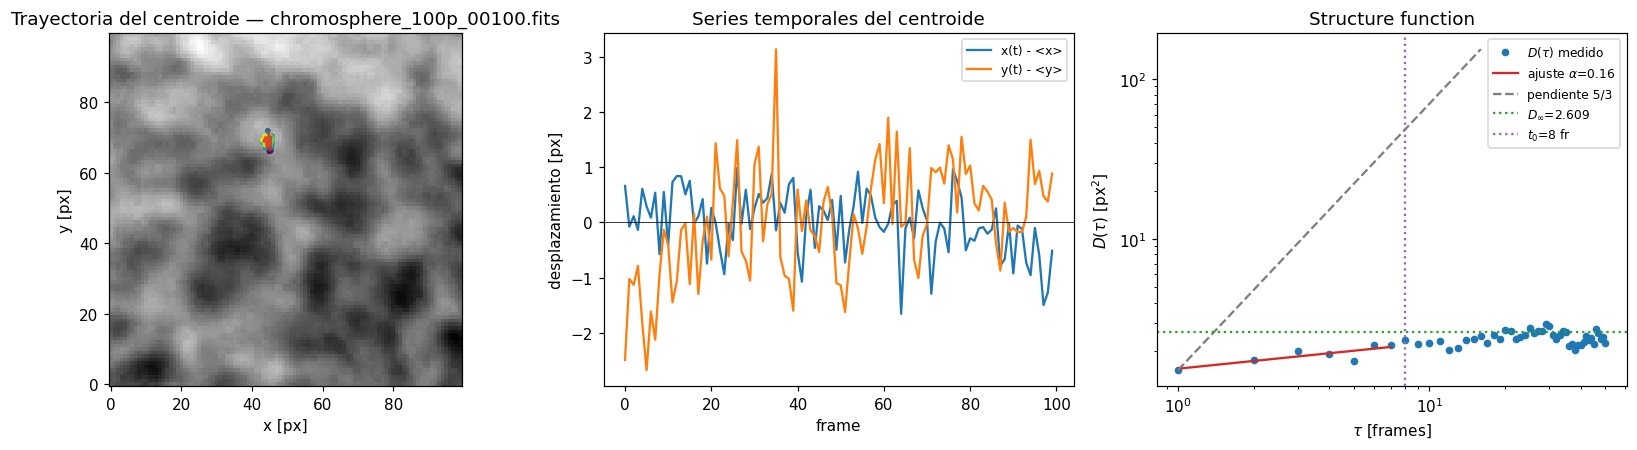

In [11]:
files = list_fits_files(kind='chromosphere', pix=100)
print(f'Total cubos disponibles: {len(files)}')

sample_path = files[0]
cube_sample, meta_sample = load_fits_cube(sample_path)
result_sample = process_file(sample_path)

print(f'Archivo  : {result_sample["file"]}')
print(f'Frames   : {result_sample["n_frames"]}')
print(f'dt       : {result_sample["dt_s"]*1e3:.2f} ms/frame (de EXPOSURE)')
print(f'alpha    : {result_sample["alpha"]:.3f}   (Kolmogorov esperado = 1.667)')
print(f'A        : {result_sample["A"]:.4e} px^2')
print(f'D_inf    : {result_sample["D_inf"]:.4f} px^2')
print(f't0       : {result_sample["t0_frames"]:.1f} frames  ({result_sample["t0_seconds"]*1e3:.2f} ms)')

plot_result(result_sample, cube=cube_sample, title_suffix=f' — {result_sample["file"]}')

## 9. Ejecución masiva sobre el dataset

Procesa todos los cubos (o un subconjunto) y agrega los resultados en un resumen tabular.

Ajustá `MAX_FILES = None` para correr todo el dataset, o un entero pequeño para una primera pasada.

In [14]:
MAX_FILES = None              # None -> procesa todo
KIND      = 'chromosphere'   # 'chromosphere' | 'continuum' | None
PIX       = 100              # 100 | 200 | None

files = list_fits_files(kind=KIND, pix=PIX)
if MAX_FILES is not None:
    files = files[:MAX_FILES]
print(f'Procesando {len(files)} archivos...')

summary = []
results = []
for i, p in enumerate(files, 1):
    res = process_file(p)
    results.append(res)
    summary.append({
        'file': res['file'],
        'instrume': res['instrume'],
        'n_frames': res['n_frames'],
        'alpha': res['alpha'],
        'A_px2': res['A'],
        't0_frames': res['t0_frames'],
        't0_ms': res['t0_seconds'] * 1e3 if np.isfinite(res['t0_seconds']) else np.nan,
        'D_inf_px2': res['D_inf'],
    })
    if i % 5 == 0 or i == len(files):
        print(f'  {i}/{len(files)}  -> {res["file"]}  alpha={res["alpha"]:.2f}  t0={res["t0_frames"]:.1f}fr')

try:
    import pandas as pd
    df = pd.DataFrame(summary)
    print('\nEstadísticas:')
    print(df[['alpha', 't0_frames', 't0_ms', 'D_inf_px2']].describe())
    print('\nPrimeras filas:')
    print(df.head(10).to_string(index=False))
except ImportError:
    for row in summary[:10]:
        print(row)

Procesando 100 archivos...
  5/100  -> chromosphere_100p_00104.fits  alpha=0.34  t0=2.0fr
  10/100  -> chromosphere_100p_00109.fits  alpha=0.43  t0=2.0fr
  15/100  -> chromosphere_100p_00114.fits  alpha=0.12  t0=3.0fr
  20/100  -> chromosphere_100p_00119.fits  alpha=0.15  t0=11.0fr
  25/100  -> chromosphere_100p_00124.fits  alpha=0.42  t0=3.0fr
  30/100  -> chromosphere_100p_00129.fits  alpha=0.09  t0=27.0fr
  35/100  -> chromosphere_100p_00134.fits  alpha=0.10  t0=15.0fr
  40/100  -> chromosphere_100p_00139.fits  alpha=0.13  t0=30.0fr
  45/100  -> chromosphere_100p_00144.fits  alpha=0.05  t0=14.0fr
  50/100  -> chromosphere_100p_00149.fits  alpha=0.05  t0=1.0fr
  55/100  -> chromosphere_100p_00154.fits  alpha=0.28  t0=5.0fr
  60/100  -> chromosphere_100p_00159.fits  alpha=0.15  t0=2.0fr
  65/100  -> chromosphere_100p_00164.fits  alpha=0.08  t0=32.0fr
  70/100  -> chromosphere_100p_00169.fits  alpha=0.04  t0=9.0fr
  75/100  -> chromosphere_100p_00174.fits  alpha=0.30  t0=10.0fr
  80/10

## 10. Distribuciones agregadas

- Histograma de la pendiente $\alpha$ → ¿qué tan consistente es con 5/3?
- Histograma del tiempo de coherencia $t_{0}$ → caracterización estadística del *seeing* en el dataset.
- Superposición de todas las $D(\tau)$ → variabilidad atmosférica entre cubos.

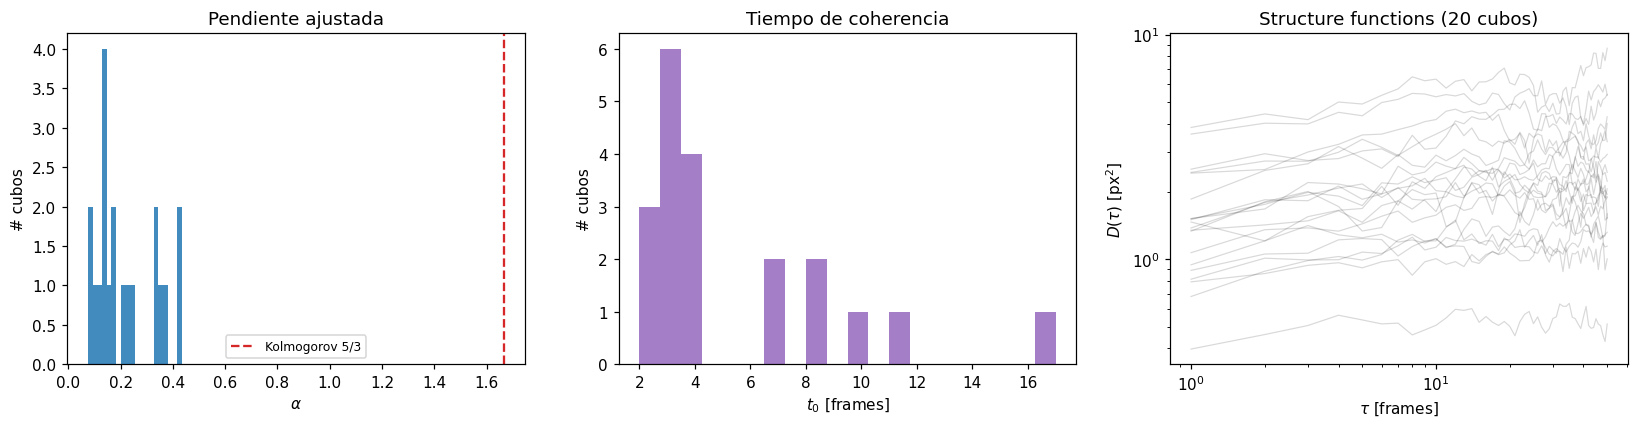

alpha   : mean=0.220  median=0.176  std=0.113
t0 [fr] : mean=5.40  median=4.00  std=3.76
D_inf   : mean=2.5289 px^2


In [13]:
alphas = np.array([r['alpha']     for r in results])
t0s_fr = np.array([r['t0_frames'] for r in results])
D_infs = np.array([r['D_inf']     for r in results])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(alphas[np.isfinite(alphas)], bins=20, color='tab:blue', alpha=0.85)
ax.axvline(5/3, color='tab:red', ls='--', label='Kolmogorov 5/3')
ax.set_xlabel(r'$\alpha$'); ax.set_ylabel('# cubos')
ax.set_title('Pendiente ajustada')
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(t0s_fr[np.isfinite(t0s_fr)], bins=20, color='tab:purple', alpha=0.85)
ax.set_xlabel(r'$t_0$ [frames]'); ax.set_ylabel('# cubos')
ax.set_title('Tiempo de coherencia')

ax = axes[2]
for r in results:
    mask = np.isfinite(r['D']) & (r['D'] > 0)
    ax.loglog(r['taus'][mask], r['D'][mask], color='k', alpha=0.15, lw=0.8)
ax.set_xlabel(r'$\tau$ [frames]'); ax.set_ylabel(r'$D(\tau)$ [px$^2$]')
ax.set_title(f'Structure functions ({len(results)} cubos)')

plt.tight_layout()
plt.show()

print(f'alpha   : mean={np.nanmean(alphas):.3f}  median={np.nanmedian(alphas):.3f}  std={np.nanstd(alphas):.3f}')
print(f't0 [fr] : mean={np.nanmean(t0s_fr):.2f}  median={np.nanmedian(t0s_fr):.2f}  std={np.nanstd(t0s_fr):.2f}')
print(f'D_inf   : mean={np.nanmean(D_infs):.4f} px^2')

## 11. Notas e interpretación

- **`alpha` cercano a 5/3**: confirma que el desplazamiento del centroide es compatible con turbulencia de Kolmogorov. Pendientes muy distintas pueden indicar movimiento real de la escena, vibración del montaje, estructura insuficiente, o — **caso típico de este dataset** — que el tiempo de coherencia $t_{0}$ es del orden de unos pocos frames y el régimen inercial queda sub-muestreado.
- **Régimen inercial sub-muestreado**: con $\mathrm{EXPOSURE}=30\,\mathrm{ms}$ y $t_{0}\sim 60$–$300\,\mathrm{ms}$, sólo $\lesssim 3$ lags caen en la zona donde la ley 5/3 es válida. Por eso el ajuste se restringe automáticamente a $\tau < t_{0}$ (doble pasada). Para recuperar bien el 5/3 haría falta una cadencia ~10× mayor.
- **`t0` (frames / ms)**: escala temporal por debajo de la cual el tilt está correlacionado. Es la pista directa de qué cadencia mínima se necesita para que un algoritmo de corrección (ej. *shift-and-add*, *lucky imaging*) capture la dinámica.
- **`D_inf`**: nivel de saturación; refleja la amplitud total del jitter atmosférico en el cubo (`Var(x)+Var(y)` × 2).
- La cadencia real frame-a-frame **no** está en `EXPOSURE`. Si más adelante se conoce un *frame interval* en el header (ej. `CDELT3`), conviene reemplazar `dt_s` en `process_file` para que `t0_seconds` quede en unidades físicas exactas.